# Code Assignment 19 — Baseline vs. ARIMA on NYC COVID-19 Daily Cases

**Dataset:** NYC DOHMH — *COVID-19 Daily Counts of Cases, Hospitalizations, and Deaths*  
**Target Variable:** `CASE_COUNT`  
**Goal:** Create a **daily** time series, do a **chronological 80/20 split**, run **ADF on differenced time series be sure to use the TRAIN**, then implement a **Baseline model** and **two ARIMA models** and compare **RMSE**.



## Instructor Guidance (some of these steps will be done for you -- look for the "RUN CELL WITHOUT CHANGES" comment)

**Plan**
1) **Load  CSV** → normalize column names; ensure a proper datetime column.  
2) **Select target** `case_count`; coerce to numeric (strip commas).  
3) **Daily index** + **linear interpolation** (fill small gaps).  
4) **Chronological split (80/20)**: first 80% → TRAIN; last 20% → TEST.  
5) **ADF on differenced TRAIN** (provided).  
6) **Student builds**:
   - **Baseline (shift/naïve)** forecast for TEST; compute **RMSE**.  
   - **ARIMA #1**: pick `(p,d,q)`; fit on TRAIN; forecast into TEST; RMSE.  
   - **ARIMA #2**: pick a different `(p,d,q)`; repeat; RMSE.  
7) **Compare RMSEs** and reflect which model beat baseline and by how much.

**Documentation topics to lookup** 
- `statsmodels.tsa.arima.model.ARIMA`  
- `statsmodels.tsa.stattools.adfuller`  
- `sklearn.metrics.mean_squared_error`

### Step 0:  Import Packages

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

### Step 1:  Load CSV, Keep Needed Columns, Change time column to a datetime object

In [145]:
DATA_PATH = "../data/covid copy.csv"

df = pd.read_csv(DATA_PATH)


date_col = "date_of_interest"
target_col = "CASE_COUNT"

# Parse date and sort
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

#df = df[df['date_of_interest'] > "2025-06-01"]

# Keep only what we need
df = df[[date_col, target_col]].copy()

df.head()

,date_of_interest,CASE_COUNT
0,2020-02-29,1
1,2020-03-01,0
2,2020-03-02,0
3,2020-03-03,1
4,2020-03-04,5


### Step 2:  Make a daily series for CASE_COUNT (fill tiny gaps linearly)

In [146]:
s = df.set_index(date_col)[target_col].asfreq("D")

s = pd.to_numeric(s.astype(str).str.replace(",", ""))

s = s.astype("float64")
#Do a linear interpolation on the series 
s = s.interpolate(method='linear')

print("Range:", s.index.min().date(), "→", s.index.max().date(), "| Length:", len(s))
s.head()



Range: 2020-02-29 → 2025-10-13 | Length: 2054


date_of_interest
2020-02-29   1.000
2020-03-01   0.000
2020-03-02   0.000
2020-03-03   1.000
2020-03-04   5.000
Freq: D, Name: CASE_COUNT, dtype: float64

### Step 3: Chronological split: first 80% TRAIN, last 20% TEST

Train: 2020-02-29 → 2024-08-28 | n = 1643
Test : 2024-08-29 → 2025-10-13 | n = 411


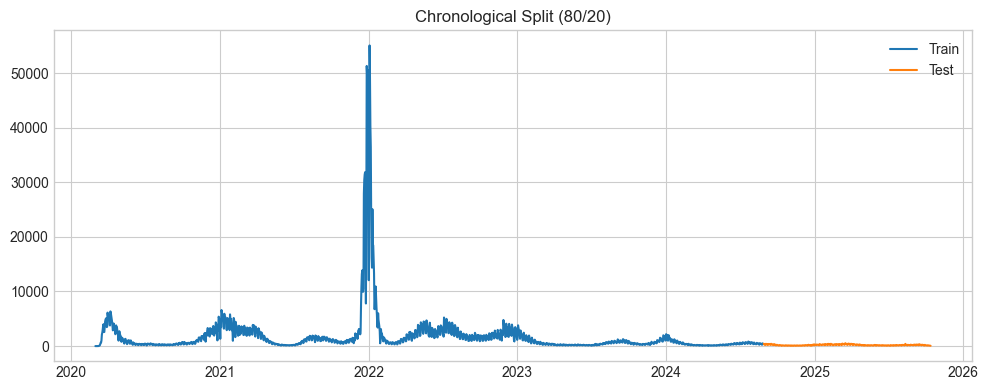

In [147]:
#RUN THIS CELL WITHOUT CHANGES 

split_idx = int(len(s) * 0.80)
train = s.iloc[:split_idx]
test  = s.iloc[split_idx:]

print("Train:", train.index.min().date(), "→", train.index.max().date(), "| n =", len(train))
print("Test :", test.index.min().date(),  "→", test.index.max().date(),  "| n =", len(test))

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test,  label="Test", color="#ff7f0e")
plt.title("Chronological Split (80/20)")
plt.legend()
plt.tight_layout()
plt.show()

### Step 4:  ADF on DIFFERENCED TRAINING data 

In [148]:
# RUN THIS CELL WITHOUT CHANGES

diff_train = train.diff().dropna()
adf_stat, adf_p, _, _, crit, _ = adfuller(diff_train)

print(f"ADF on differenced TRAIN: stat={adf_stat:.3f}, p={adf_p:.4f}")
for k, v in crit.items():
    print(f"  critical {k}: {v:.3f}")
print("\nIf p < 0.05, using d=1 in ARIMA is reasonable.")

ADF on differenced TRAIN: stat=-9.677, p=0.0000
  critical 1%: -3.434
  critical 5%: -2.863
  critical 10%: -2.568

If p < 0.05, using d=1 in ARIMA is reasonable.


### Step 5:  Create a baseline shift model (use a shift of 1) and calculate the RMSE

- Plot the model (Actual vs. Prediction)

Baseline RMSE: 215.047


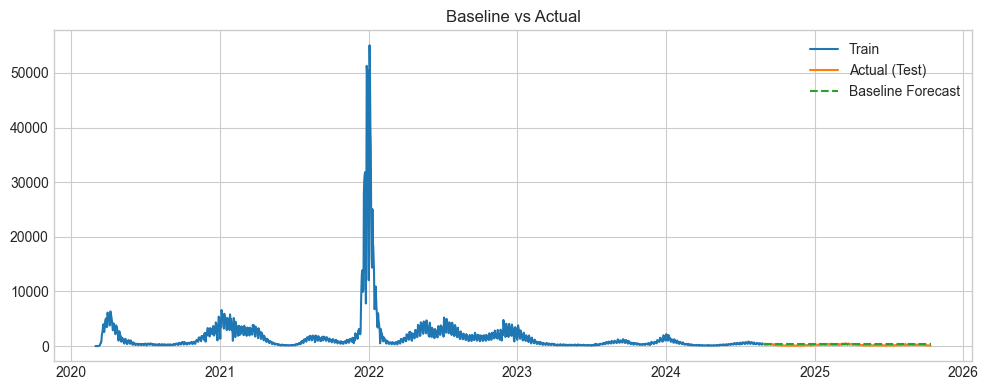

date_of_interest
2024-08-29   392.000
2024-08-30   392.000
2024-08-31   392.000
2024-09-01   392.000
2024-09-02   392.000
               ...  
2025-10-09   392.000
2025-10-10   392.000
2025-10-11   392.000
2025-10-12   392.000
2025-10-13   392.000
Freq: D, Length: 411, dtype: float64

In [149]:
baseline_pred = pd.Series(train.iloc[-1], index=test.index)
rmse_baseline = np.sqrt(mean_squared_error(test,baseline_pred))
print(f"Baseline RMSE: {rmse_baseline:,.3f}")

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Actual (Test)", color="#ff7f0e")
plt.plot(baseline_pred, label="Baseline Forecast", color="#2ca02c", linestyle="--")
plt.title("Baseline vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

baseline_pred

### Step 6:  Create an ARIMA (1,1,1) model:  Fit on TRAIN, forecast into TEST, calculate RMSE
- Plot the visual of the model

Arima (1,1,1) RMSE: 261.128


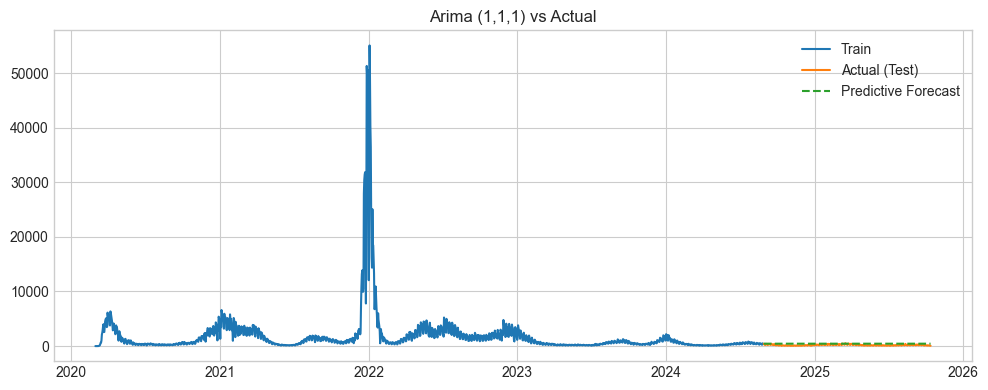

2024-08-29   452.572
2024-08-30   440.572
2024-08-31   442.949
2024-09-01   442.478
2024-09-02   442.571
               ...  
2025-10-09   442.556
2025-10-10   442.556
2025-10-11   442.556
2025-10-12   442.556
2025-10-13   442.556
Freq: D, Name: predicted_mean, Length: 411, dtype: float64

In [150]:
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

predictions = model_fit.forecast(steps=len(test))
arima_rmse = np.sqrt(mean_squared_error(test, predictions))

print(f"Arima (1,1,1) RMSE: {arima_rmse:,.3f}")

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Actual (Test)", color="#ff7f0e")
plt.plot(predictions, label="Predictive Forecast", color="#2ca02c", linestyle="--")
plt.title("Arima (1,1,1) vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

predictions

### Step 7:  Create an ARIMA(2,1,1):  Fit on TRAIN, forecast into TEST, calculate RMSE
- Plot the visual of the model

Arima (2,1,1) RMSE: 220.662


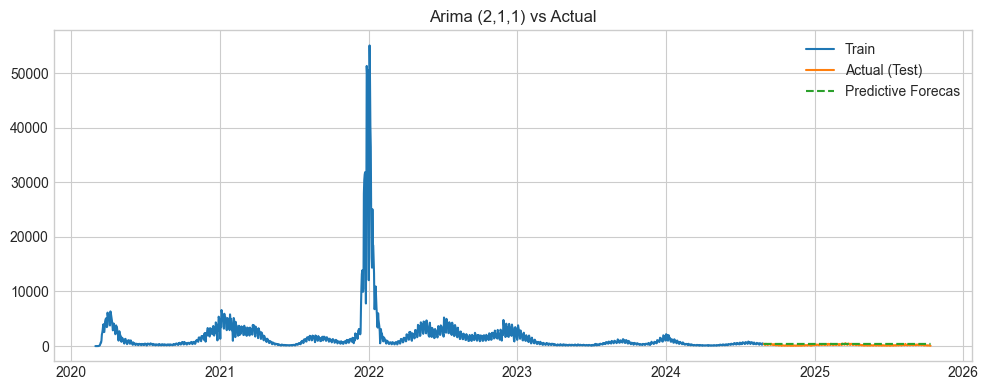

2024-08-29   403.626
2024-08-30   405.537
2024-08-31   400.912
2024-09-01   396.466
2024-09-02   395.555
               ...  
2025-10-09   398.278
2025-10-10   398.278
2025-10-11   398.278
2025-10-12   398.278
2025-10-13   398.278
Freq: D, Name: predicted_mean, Length: 411, dtype: float64

In [153]:
modelnew = ARIMA(train, order=(2,1,1))
model_newfit = modelnew.fit()

newpredictions = model_newfit.forecast(steps=len(test))
newarima_rmse = np.sqrt(mean_squared_error(test, newpredictions))

print(f"Arima (2,1,1) RMSE: {newarima_rmse:,.3f}")

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Actual (Test)", color="#ff7f0e")
plt.plot(newpredictions, label="Predictive Forecas", color="#2ca02c", linestyle="--")
plt.title("Arima (2,1,1) vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

newpredictions

## Reflection (We Share)
- Which ARIMA order performed best vs. baseline? By how much (%) did it reduce RMSE?

Between the two ARIMA models, the ARIMA(2,1,1) model performed better overall. Increasing the autoregressive term to 2 and adjusting the lag structure improved the RMSE to 220.62, compared with 261.12 for the ARIMA(1,1,1) model. Despite this improvement, neither ARIMA model outperformed the naïve baseline model. ARIMA(2,1,1) missed the benchmark by about 5 points, while ARIMA(1,1,1) lagged behind by about 40 points.

- If neither ARIMA beat baseline, what’s your next step (different d, seasonal naïve, SARIMA, widen training window, handle outliers)?

From what I've researched, it seems ARIMA is best suitable for data less than six months due to the model's autoregressive influence weakens as the time period lengthens. Going forward, we can truncate the data to a year and predict 6 months into the future, ensuring accuracy of our predictions.